<a href="https://colab.research.google.com/github/arghyadutta7878-alt/automotive_object_detection/blob/main/automotive_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics torchmetrics opencv-python matplotlib pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.0 MB/s eta 0:00:00


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Automotive Engine Part Detection.v1i.yolov8.zip to Automotive Engine Part Detection.v1i.yolov8.zip


In [4]:
print(uploaded.keys())

dict_keys(['Automotive Engine Part Detection.v1i.yolov8.zip'])


In [5]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/automotive_dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Location:", extract_path)

Dataset extracted successfully.
Location: /content/automotive_dataset


In [6]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

        for file in files[:5]:
            print("  " * (level + 1) + file)

automotive_dataset/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  test/
    labels/
      car_part_detection_002571_jpg.rf.87efc72aa498e67f85bd6c73a6e89b19.txt
      car_part_detection_002221_jpg.rf.f616041cfbf0226ed7134be19662c9be.txt
      car_part_detection_001603_jpg.rf.b561fc45782798415a6d121f465fb7e3.txt
      car_part_detection_001873_jpg.rf.c6fb087f5453e8ae36e929019bf9cc05.txt
      car_part_detection_002525_jpg.rf.ea159074d3cf02468bbe3b4bad346a68.txt
    images/
      car_part_detection_002326_jpg.rf.aaa61717761c8a58b73fa495a6a0dcb2.jpg
      car_part_detection_002026_jpg.rf.102593f18ce381c8908d4aaf04190f93.jpg
      car_part_detection_001002_jpg.rf.2cb9000c96478dbbb6d2f26fa3326c78.jpg
      car_part_detection_000077_jpg.rf.75c74311b8fdc3e9dad6cdea1d899c60.jpg
      car_part_detection_001358_jpg.rf.9a83f9032d8c38ba13b31c27429b2796.jpg
  valid/
    labels/
      car_part_detection_001045_jpg.rf.434739d2f381fd63220060bc56bcc985.txt
      car_part_detection_002747_jpg.

In [7]:
import glob

yaml_files = glob.glob(
    "/content/automotive_dataset/**/*.yaml",
    recursive=True
)

print(yaml_files)

['/content/automotive_dataset/data.yaml']


In [8]:
DATA_YAML = yaml_files[0]

print("Dataset YAML:")
print(DATA_YAML)

Dataset YAML:
/content/automotive_dataset/data.yaml


In [9]:
import yaml

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['Air intake', 'Battery', 'Brake oil', 'Collant', 'Fuse Box', 'Main Engine', 'Oil cap', 'Radiator', 'Sprinkler'], 'roboflow': {'workspace': 'ahsan-abdullah-omu7t', 'project': 'automotive-engine-part-detection', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ahsan-abdullah-omu7t/automotive-engine-part-detection/dataset/1'}}


In [10]:
names = data_config["names"]

print("Number of classes:", len(names))
print("Classes:")

for i, name in enumerate(names):
    print(i, ":", name)

Number of classes: 9
Classes:
0 : Air intake
1 : Battery
2 : Brake oil
3 : Collant
4 : Fuse Box
5 : Main Engine
6 : Oil cap
7 : Radiator
8 : Sprinkler


In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

image_files = glob.glob(
    "/content/automotive_dataset/**/*.jpg",
    recursive=True
)

if len(image_files) == 0:
    image_files = glob.glob(
        "/content/automotive_dataset/**/*.png",
        recursive=True
    )

print("Total images found:", len(image_files))

Total images found: 2407


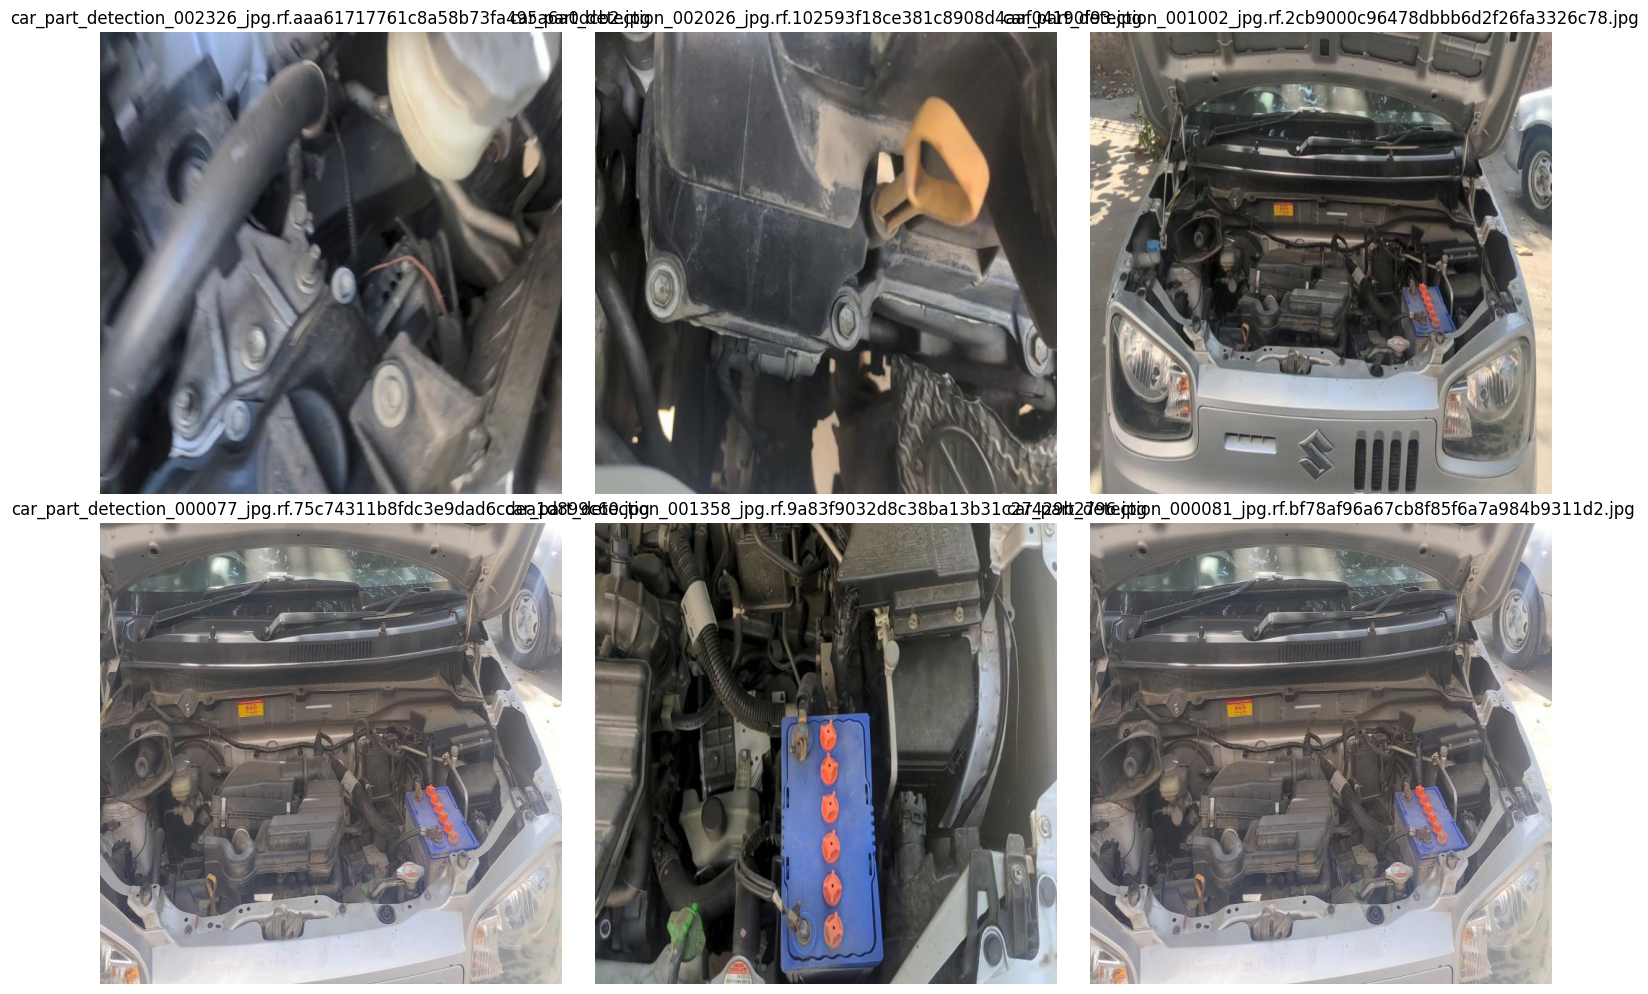

In [12]:
sample_images = image_files[:6]

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):

    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(image_path))

plt.tight_layout()
plt.show()

In [13]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [14]:
model = YOLO("yolov8n.pt")

In [15]:
results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    workers=2,
    project="/content/automotive_project",
    name="yolov8_engine_parts"
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/automotive_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_engine_parts, nbs=64, nms=None, opset=None, 

In [16]:
import os

results_folder = "/content/automotive_project/yolov8_engine_parts"

print(os.listdir(results_folder))

['results.csv', 'BoxR_curve.png', 'train_batch1.jpg', 'val_batch2_pred.jpg', 'confusion_matrix_normalized.png', 'val_batch1_pred.jpg', 'weights', 'val_batch1_labels.jpg', 'results.png', 'train_batch2001.jpg', 'BoxPR_curve.png', 'BoxP_curve.png', 'val_batch2_labels.jpg', 'train_batch2000.jpg', 'confusion_matrix.png', 'labels.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'train_batch2002.jpg', 'val_batch0_pred.jpg', 'train_batch0.jpg', 'BoxF1_curve.png', 'args.yaml']


In [17]:
BEST_MODEL = "/content/automotive_project/yolov8_engine_parts/weights/best.pt"

print(os.path.exists(BEST_MODEL))

True


In [18]:
trained_model = YOLO(BEST_MODEL)

In [19]:
metrics = trained_model.val(
    data=DATA_YAML,
    imgsz=640,
    device=0
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1376.2±285.3 MB/s, size: 47.2 KB)
val: Scanning /content/automotive_dataset/valid/labels.cache... 481 images, 1 backgrounds, 31 corrupt: 100% ━━━━━━━━━━━━ 481/481 144.1Mit/s 0.0s
val: /content/automotive_dataset/valid/images/car_part_detection_000004_jpg.rf.f582bb623e436056989895d2f271130c.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/automotive_dataset/valid/images/car_part_detection_001004_jpg.rf.2a4dde17fa9df77ea174f47ea981417c.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/automotive_dataset/valid/images/car_part_detection_001007_jpg.rf.c690cdddb4a0e4342360385322f844e2.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/automotive_dataset/valid/images/car_pa

In [20]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

mAP50: 0.9557048352316235
mAP50-95: 0.8171610213132701


In [21]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Precision: 0.9342211167523783
Recall: 0.9209137400360334


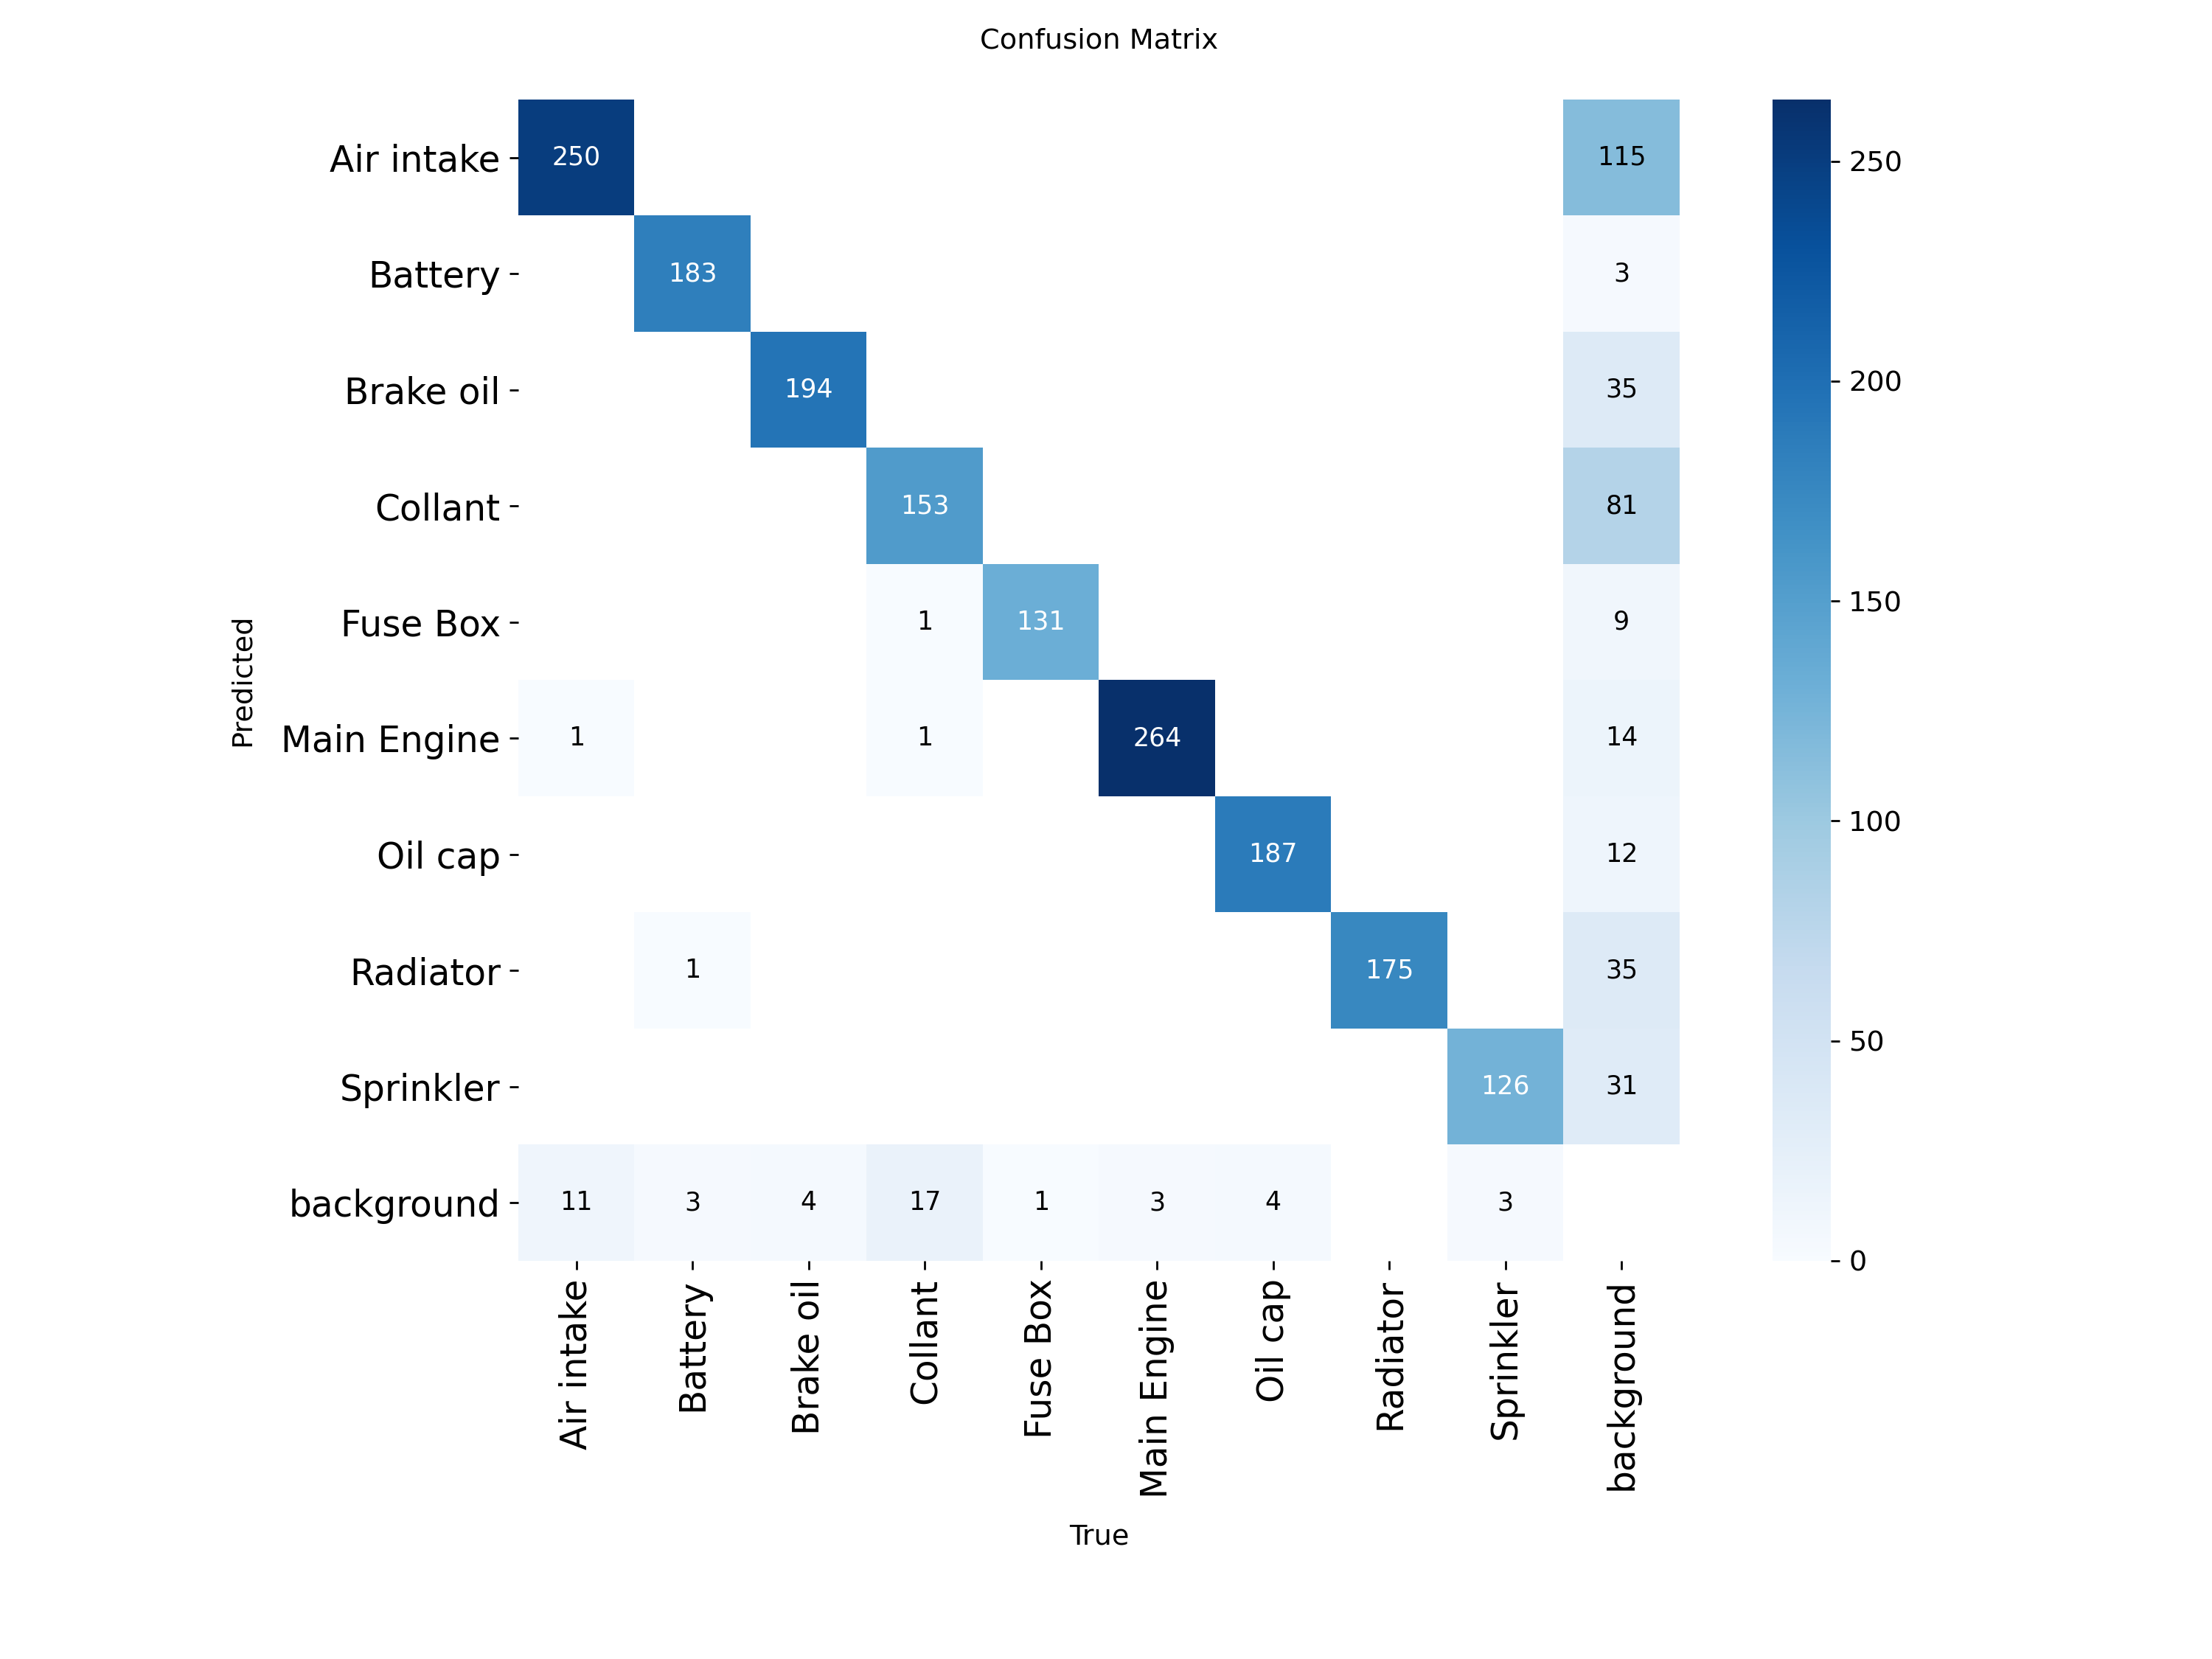

In [22]:
from IPython.display import Image as IPImage, display

display(
    IPImage(
        filename="/content/automotive_project/yolov8_engine_parts/confusion_matrix.png"
    )
)

In [23]:
test_images = glob.glob(
    "/content/automotive_dataset/test/images/*"
)

print("Test images:", len(test_images))

Test images: 241


In [24]:
test_image = test_images[0]

print(test_image)

/content/automotive_dataset/test/images/car_part_detection_002326_jpg.rf.aaa61717761c8a58b73fa495a6a0dcb2.jpg


In [25]:
prediction = trained_model.predict(
    source=test_image,
    conf=0.40,
    imgsz=640
)


image 1/1 /content/automotive_dataset/test/images/car_part_detection_002326_jpg.rf.aaa61717761c8a58b73fa495a6a0dcb2.jpg: 640x640 1 Brake oil, 8.6ms
Speed: 1.1ms preprocess, 8.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


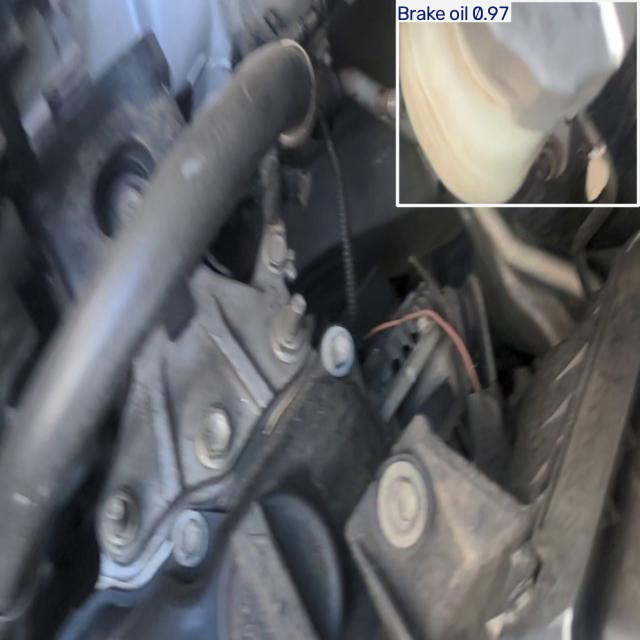

In [26]:
prediction[0].show()

In [27]:
component_info = {
    "Battery": "Supplies electrical power to the vehicle.",
    "Air intake": "Supplies air required for engine combustion.",
    "Brake oil": "Transfers hydraulic pressure in the braking system.",
    "Collant": "Helps control engine temperature.",
    "Fuse Box": "Protects electrical circuits from excessive current.",
    "Main Engine": "Main power-producing component of the vehicle.",
    "Oil cap": "Provides access for adding engine oil.",
    "Radiator": "Removes heat from engine coolant.",
    "Sprinkler": "Used for fluid spraying in the vehicle."
}

for name, info in component_info.items():
    print(name, ":", info)

Battery : Supplies electrical power to the vehicle.
Air intake : Supplies air required for engine combustion.
Brake oil : Transfers hydraulic pressure in the braking system.
Collant : Helps control engine temperature.
Fuse Box : Protects electrical circuits from excessive current.
Main Engine : Main power-producing component of the vehicle.
Oil cap : Provides access for adding engine oil.
Radiator : Removes heat from engine coolant.
Sprinkler : Used for fluid spraying in the vehicle.


In [28]:
trained_model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [29]:
print(BEST_MODEL)

/content/automotive_project/yolov8_engine_parts/weights/best.pt


In [30]:
from ultralytics import YOLO

trained_model = YOLO(BEST_MODEL)

print("Model loaded successfully!")

Model loaded successfully!


In [34]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
from io import BytesIO

display(Javascript("""
async function takePhoto() {

    const video = document.createElement('video');

    video.style.width = '640px';
    video.style.height = '480px';
    video.style.objectFit = 'cover';

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;

    await video.play();

    // Wait for the camera to produce a frame
    await new Promise(resolve => setTimeout(resolve, 1000));

    const canvas = document.createElement('canvas');

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    const context = canvas.getContext('2d');

    context.drawImage(
        video,
        0,
        0,
        canvas.width,
        canvas.height
    );

    const image = canvas.toDataURL(
        'image/jpeg',
        0.8
    );

    stream.getVideoTracks()[0].stop();
    video.remove();

    return image;
}
"""))

print("Camera function loaded successfully.")

<IPython.core.display.Javascript object>

Camera function loaded successfully.


In [36]:
from google.colab import files

files.download(
    "/content/automotive_project/yolov8_engine_parts/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import os

print("Dataset location:", "/content/automotive_dataset")

for folder in ["train", "valid", "test"]:
    path = f"/content/automotive_dataset/{folder}"
    print(f"\n{folder}:")
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        print(os.listdir(path))

Dataset location: /content/automotive_dataset

train:
Exists: True
['labels.cache', 'labels', 'images']

valid:
Exists: True
['labels.cache', 'labels', 'images']

test:
Exists: True
['labels', 'images']


In [38]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True
GPU: Tesla T4


In [39]:
import os
import cv2
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader

class AutomotiveDataset(Dataset):

    def __init__(self, root, split="train"):
        self.image_dir = os.path.join(root, split, "images")
        self.label_dir = os.path.join(root, split, "labels")

        self.images = sorted([
            f for f in os.listdir(self.image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image_name = self.images[index]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        label_name = os.path.splitext(image_name)[0] + ".txt"

        label_path = os.path.join(
            self.label_dir,
            label_name
        )

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            raise ValueError(f"Could not read image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        height, width = image.shape[:2]

        # Convert image to tensor
        image = torch.from_numpy(image).permute(2, 0, 1)
        image = image.float() / 255.0

        boxes = []
        labels = []

        # Read YOLO labels
        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id = int(values[0])

                    x_center = float(values[1]) * width
                    y_center = float(values[2]) * height
                    box_width = float(values[3]) * width
                    box_height = float(values[4]) * height

                    x1 = x_center - box_width / 2
                    y1 = y_center - box_height / 2
                    x2 = x_center + box_width / 2
                    y2 = y_center + box_height / 2

                    # Keep boxes inside image
                    x1 = max(0, min(x1, width))
                    y1 = max(0, min(y1, height))
                    x2 = max(0, min(x2, width))
                    y2 = max(0, min(y2, height))

                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])

                        # +1 because 0 is background in torchvision
                        labels.append(class_id + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32)

        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([index])
        }

        return image, target

In [40]:
DATASET_ROOT = "/content/automotive_dataset"

train_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "train"
)

valid_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "valid"
)

test_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "test"
)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

Training images: 1685
Validation images: 481
Test images: 241


In [41]:
def collate_fn(batch):
    return tuple(zip(*batch))


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [42]:
images, targets = next(iter(train_loader))

print("Number of images:", len(images))
print("Image shape:", images[0].shape)
print("Boxes:", targets[0]["boxes"])
print("Labels:", targets[0]["labels"])

Number of images: 8
Image shape: torch.Size([3, 640, 640])
Boxes: tensor([[250.2500, 404.2500, 435.7500, 639.7500]])
Labels: tensor([7])


In [43]:
NUM_CLASSES = 10  # 9 automotive classes + background

print("Number of classes:", NUM_CLASSES)

Number of classes: 10


In [44]:
import torch
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_ssd = ssdlite320_mobilenet_v3_large(
    weights=None,
    weights_backbone="DEFAULT",
    num_classes=NUM_CLASSES
)

model_ssd = model_ssd.to(device)

print("SSD model created successfully.")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 87.2MB/s]


SSD model created successfully.
Device: cuda


In [45]:
import torch.optim as optim

optimizer = optim.SGD(
    model_ssd.parameters(),
    lr=0.002,
    momentum=0.9,
    weight_decay=0.0005
)

print("Optimizer created.")

Optimizer created.


In [47]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader


class AutomotiveDataset(Dataset):

    def __init__(self, root, split="train"):
        self.image_dir = os.path.join(root, split, "images")
        self.label_dir = os.path.join(root, split, "labels")

        self.images = sorted([
            f for f in os.listdir(self.image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image_name = self.images[index]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        label_name = os.path.splitext(image_name)[0] + ".txt"

        label_path = os.path.join(
            self.label_dir,
            label_name
        )

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            raise ValueError(f"Could not read image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        height, width = image.shape[:2]

        # Image tensor
        image = torch.from_numpy(image).permute(2, 0, 1)
        image = image.float() / 255.0

        boxes = []
        labels = []

        # Read YOLO annotation
        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    try:
                        class_id = int(values[0])

                        x_center = float(values[1]) * width
                        y_center = float(values[2]) * height
                        box_width = float(values[3]) * width
                        box_height = float(values[4]) * height

                    except ValueError:
                        continue

                    x1 = x_center - box_width / 2
                    y1 = y_center - box_height / 2
                    x2 = x_center + box_width / 2
                    y2 = y_center + box_height / 2

                    # Clip coordinates
                    x1 = max(0, min(x1, width))
                    y1 = max(0, min(y1, height))
                    x2 = max(0, min(x2, width))
                    y2 = max(0, min(y2, height))

                    # Only keep valid boxes
                    if x2 > x1 and y2 > y1:

                        boxes.append([
                            x1,
                            y1,
                            x2,
                            y2
                        ])

                        # Background = 0
                        # Automotive classes = 1 to 9
                        labels.append(class_id + 1)

        # IMPORTANT:
        # Empty boxes must have shape [0, 4]
        if len(boxes) == 0:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        else:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([index])
        }

        return image, target

In [48]:
DATASET_ROOT = "/content/automotive_dataset"

train_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "train"
)

valid_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "valid"
)

test_dataset = AutomotiveDataset(
    DATASET_ROOT,
    "test"
)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

Training images: 1685
Validation images: 481
Test images: 241


In [49]:
def collate_fn(batch):
    return tuple(zip(*batch))


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("DataLoaders recreated successfully.")

DataLoaders recreated successfully.


In [50]:
images, targets = next(iter(train_loader))

for i, target in enumerate(targets):
    print(
        f"Image {i}: "
        f"boxes shape = {target['boxes'].shape}, "
        f"labels shape = {target['labels'].shape}"
    )

Image 0: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 1: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 2: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 3: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 4: boxes shape = torch.Size([1, 4]), labels shape = torch.Size([1])
Image 5: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 6: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])
Image 7: boxes shape = torch.Size([0, 4]), labels shape = torch.Size([0])


In [51]:
import torch
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

NUM_CLASSES = 10

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_ssd = ssdlite320_mobilenet_v3_large(
    weights=None,
    weights_backbone="DEFAULT",
    num_classes=NUM_CLASSES
)

model_ssd = model_ssd.to(device)

print("SSD model ready.")
print("Device:", device)

SSD model ready.
Device: cuda


In [52]:
import torch.optim as optim

optimizer = optim.SGD(
    model_ssd.parameters(),
    lr=0.002,
    momentum=0.9,
    weight_decay=0.0005
)

print("Optimizer ready.")

Optimizer ready.


In [53]:
num_epochs = 5

print("Starting SSD training...")

for epoch in range(num_epochs):

    model_ssd.train()

    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):

        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                key: value.to(device)
                for key, value in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad()

        loss_dict = model_ssd(
            images,
            targets
        )

        losses = sum(loss for loss in loss_dict.values())

        losses.backward()

        optimizer.step()

        total_loss += losses.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Batch [{batch_idx + 1}/{len(train_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Average Loss: {average_loss:.4f}"
    )

print("SSD training completed successfully.")

Starting SSD training...
Epoch [1/5] Batch [50/211] Loss: 0.0000
Epoch [1/5] Batch [100/211] Loss: 8.7128
Epoch [1/5] Batch [150/211] Loss: 4.4127
Epoch [1/5] Batch [200/211] Loss: 11.5354
Epoch [1/5] Average Loss: 5.9919
Epoch [2/5] Batch [50/211] Loss: 2.4331
Epoch [2/5] Batch [100/211] Loss: 4.1347
Epoch [2/5] Batch [150/211] Loss: 3.5489
Epoch [2/5] Batch [200/211] Loss: 3.0176
Epoch [2/5] Average Loss: 2.9571
Epoch [3/5] Batch [50/211] Loss: 1.4287
Epoch [3/5] Batch [100/211] Loss: 1.5774
Epoch [3/5] Batch [150/211] Loss: 6.0441
Epoch [3/5] Batch [200/211] Loss: 4.2455
Epoch [3/5] Average Loss: 3.0841
Epoch [4/5] Batch [50/211] Loss: 3.0227
Epoch [4/5] Batch [100/211] Loss: 0.0000
Epoch [4/5] Batch [150/211] Loss: 2.2668
Epoch [4/5] Batch [200/211] Loss: 1.4219
Epoch [4/5] Average Loss: 2.1887
Epoch [5/5] Batch [50/211] Loss: 1.3453
Epoch [5/5] Batch [100/211] Loss: 0.0000
Epoch [5/5] Batch [150/211] Loss: 1.2291
Epoch [5/5] Batch [200/211] Loss: 1.5908
Epoch [5/5] Average Loss: 1

In [54]:
SSD_MODEL_PATH = "/content/ssd_automotive.pth"

torch.save(
    model_ssd.state_dict(),
    SSD_MODEL_PATH
)

print("SSD model saved successfully.")
print(SSD_MODEL_PATH)

SSD model saved successfully.
/content/ssd_automotive.pth


In [55]:
!pip install -q torchmetrics pycocotools

In [56]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print("MeanAveragePrecision loaded successfully.")

MeanAveragePrecision loaded successfully.


In [57]:
from tqdm.auto import tqdm

model_ssd.eval()

ssd_predictions = []
ssd_targets = []

with torch.no_grad():

    for images, targets in tqdm(test_loader):

        images_gpu = [
            image.to(device)
            for image in images
        ]

        outputs = model_ssd(images_gpu)

        for output, target in zip(outputs, targets):

            prediction = {
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu()
            }

            ground_truth = {
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            }

            ssd_predictions.append(prediction)
            ssd_targets.append(ground_truth)

print("SSD prediction completed.")
print("Number of test images:", len(ssd_predictions))

  0%|          | 0/31 [00:00<?, ?it/s]

SSD prediction completed.
Number of test images: 241


In [59]:
import torch

def calculate_precision_recall(
    predictions,
    targets,
    iou_threshold=0.5,
    score_threshold=0.5
):

    true_positives = 0
    false_positives = 0
    false_negatives = 0

    for pred, target in zip(predictions, targets):

        pred_boxes = pred["boxes"]
        pred_scores = pred["scores"]
        pred_labels = pred["labels"]

        gt_boxes = target["boxes"]
        gt_labels = target["labels"]

        # Keep only confident predictions
        keep = pred_scores >= score_threshold

        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]

        # No predictions
        if len(pred_boxes) == 0:
            false_negatives += len(gt_boxes)
            continue

        # No ground-truth objects
        if len(gt_boxes) == 0:
            false_positives += len(pred_boxes)
            continue

        matched_gt = set()

        for i in range(len(pred_boxes)):

            pred_box = pred_boxes[i]
            pred_label = pred_labels[i]

            best_iou = 0.0
            best_gt = -1

            for j in range(len(gt_boxes)):

                if j in matched_gt:
                    continue

                # Class must match
                if pred_label != gt_labels[j]:
                    continue

                gt_box = gt_boxes[j]

                # Intersection
                x1 = max(pred_box[0], gt_box[0])
                y1 = max(pred_box[1], gt_box[1])
                x2 = min(pred_box[2], gt_box[2])
                y2 = min(pred_box[3], gt_box[3])

                inter_width = max(0, x2 - x1)
                inter_height = max(0, y2 - y1)

                intersection = inter_width * inter_height

                # Areas
                pred_area = (
                    (pred_box[2] - pred_box[0]).clamp(min=0)
                    *
                    (pred_box[3] - pred_box[1]).clamp(min=0)
                )

                gt_area = (
                    (gt_box[2] - gt_box[0]).clamp(min=0)
                    *
                    (gt_box[3] - gt_box[1]).clamp(min=0)
                )

                union = pred_area + gt_area - intersection

                if union > 0:
                    iou = intersection / union
                else:
                    iou = 0

                if iou > best_iou:
                    best_iou = float(iou)
                    best_gt = j

            if best_iou >= iou_threshold and best_gt >= 0:

                true_positives += 1
                matched_gt.add(best_gt)

            else:

                false_positives += 1

        # Ground-truth objects not detected
        false_negatives += len(gt_boxes) - len(matched_gt)

    precision = (
        true_positives /
        (true_positives + false_positives)
        if (true_positives + false_positives) > 0
        else 0
    )

    recall = (
        true_positives /
        (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0
        else 0
    )

    return precision, recall

In [60]:
ssd_precision, ssd_recall = calculate_precision_recall(
    ssd_predictions,
    ssd_targets,
    iou_threshold=0.5,
    score_threshold=0.5
)

print("SSD Precision:", ssd_precision)
print("SSD Recall:", ssd_recall)

print("\nPercentage:")
print("SSD Precision:", round(ssd_precision * 100, 2), "%")
print("SSD Recall:", round(ssd_recall * 100, 2), "%")

SSD Precision: 0.371900826446281
SSD Recall: 0.6338028169014085

Percentage:
SSD Precision: 37.19 %
SSD Recall: 63.38 %


In [62]:
# Get SSD mAP values again from the calculated metrics

ssd_map50 = float(ssd_metrics["map_50"])
ssd_map5095 = float(ssd_metrics["map"])

print("SSD mAP50:", ssd_map50)
print("SSD mAP50-95:", ssd_map5095)

SSD mAP50: 0.6381258964538574
SSD mAP50-95: 0.3068971335887909


In [63]:
ssd_results = {
    "Model": "SSD",
    "mAP50": ssd_map50,
    "mAP50-95": ssd_map5095,
    "Precision": ssd_precision,
    "Recall": ssd_recall
}

print(ssd_results)

{'Model': 'SSD', 'mAP50': 0.6381258964538574, 'mAP50-95': 0.3068971335887909, 'Precision': 0.371900826446281, 'Recall': 0.6338028169014085}


In [64]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import torch

NUM_CLASSES = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_frcnn = fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone="DEFAULT",
    num_classes=NUM_CLASSES
)

model_frcnn = model_frcnn.to(device)

print("Faster R-CNN model ready!")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 106MB/s]


Faster R-CNN model ready!
Device: cuda


In [65]:
import torch.optim as optim

optimizer_frcnn = optim.SGD(
    model_frcnn.parameters(),
    lr=0.002,
    momentum=0.9,
    weight_decay=0.0005
)

In [66]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):

    model_frcnn.train()
    total_loss = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, targets in progress:

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in target.items()}
            for target in targets
        ]

        optimizer_frcnn.zero_grad()

        loss_dict = model_frcnn(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer_frcnn.step()

        total_loss += losses.item()

        progress.set_postfix(loss=losses.item())

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Average Loss: {average_loss:.4f}"
    )

print("Faster R-CNN training completed!")

Epoch 1/5: 100%|██████████| 211/211 [06:14<00:00,  1.78s/it, loss=0.0455]


Epoch [1/5] Average Loss: 0.1846


Epoch 2/5: 100%|██████████| 211/211 [06:14<00:00,  1.78s/it, loss=0.00376]


Epoch [2/5] Average Loss: 0.0960


Epoch 3/5: 100%|██████████| 211/211 [06:13<00:00,  1.77s/it, loss=0.115]


Epoch [3/5] Average Loss: 0.0773


Epoch 4/5: 100%|██████████| 211/211 [06:13<00:00,  1.77s/it, loss=0.00233]


Epoch [4/5] Average Loss: 0.0639


Epoch 5/5: 100%|██████████| 211/211 [06:13<00:00,  1.77s/it, loss=0.0405]

Epoch [5/5] Average Loss: 0.0526
Faster R-CNN training completed!


In [67]:
FRCNN_MODEL_PATH = "/content/fasterrcnn_automotive.pth"

torch.save(
    model_frcnn.state_dict(),
    FRCNN_MODEL_PATH
)

print("Saved:", FRCNN_MODEL_PATH)

Saved: /content/fasterrcnn_automotive.pth


In [68]:
import os
import shutil

BEST_MODEL = "/content/automotive_project/yolov8_engine_parts/weights/best.pt"

print("Model exists:", os.path.exists(BEST_MODEL))
print("Model path:", BEST_MODEL)

Model exists: True
Model path: /content/automotive_project/yolov8_engine_parts/weights/best.pt


In [69]:
FINAL_MODEL = "/content/final_automotive_yolo_best.pt"

shutil.copy(BEST_MODEL, FINAL_MODEL)

print("Final model created:")
print(FINAL_MODEL)
print("Size:", os.path.getsize(FINAL_MODEL) / (1024*1024), "MB")

Final model created:
/content/final_automotive_yolo_best.pt
Size: 5.961709976196289 MB


In [70]:
from google.colab import files

files.download("/content/final_automotive_yolo_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>